In [1]:
from SpaLP.utils import prepare_inputs, set_seed,create_new_color_dict,Graph
from SpaLP.LP import SpatialLocalPooling
from SpaLP.Label_Transfer import CellAnnotator
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
import scanpy as sc
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import anndata as ad
from tqdm import tqdm
import time

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

### pretraining on MERFISH mouse brain, Inference on unrelated mouse testis tissue and same mouse brain tissue

In [4]:
adata_batch1=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/STARmapPLUS/MERFISH_-1.078.h5ad')
adata_batch1.var_names_make_unique()
adata_batch1.obs['batch']='MERFISH_mouse_brain'
adata_batch1.obs['type']='Pre-training data'



adata_batch2=sc.read_h5ad('/home/dbj/SpaLA/stereoseqmousegaowan/testis.h5ad')
adata_batch2.var_names_make_unique()
adata_batch2.obs['batch']='Mouse_testis'
adata_batch2.obs['type']='Inference data'

adata_batch3=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/STARmapPLUS/MERFISH_-1.076.h5ad')
adata_batch3.var_names_make_unique()
adata_batch3.obs['batch']='MERFISH_mouse_brain'
adata_batch3.obs['type']='Inference data'

common_genes = adata_batch1.var_names.intersection(adata_batch2.var_names)
adata_batch1 = adata_batch1[:, common_genes].copy()
adata_batch2 = adata_batch2[:, common_genes].copy()
adata_batch3 = adata_batch3[:, common_genes].copy()

In [5]:
sc.pp.scale(adata_batch1)
adata_batch1.obsm['feat']=adata_batch1.X

In [6]:
k=9
graph = prepare_inputs(adata_batch1, k, device)

In [7]:
in_channels = graph.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=64).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
epochs = 200
pbar = tqdm(range(epochs), desc="Training",ncols=200)
for epoch in pbar:
    start_time = time.time()
    model.train()
    optimizer.zero_grad()
    reconstructed,embedding = model(graph.features, graph.neighbor_idx)
    loss = criterion(reconstructed, graph.features)
    loss.backward()
    optimizer.step()
    elapsed = time.time() - start_time
    pbar.set_postfix({"Epoch": epoch,"Loss": f"{loss.item():.4f}"})

Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:04<00:00, 43.03it/s, Epoch=199, Loss=0.8614]


In [9]:
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph.features, graph.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

In [10]:
adata_batch1.obsm['SpaLP']=embedding

In [11]:
torch.save(model.state_dict(), "/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/unrelatedtissues/76_pretrian_model.pth")

In [12]:
adata_batch1.write_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/unrelatedtissues/Pre-training.h5ad',compression='gzip')

### zero-shot inference embedding

In [13]:
sc.pp.scale(adata_batch2)
adata_batch2.obsm['feat']=adata_batch2.X

sc.pp.scale(adata_batch3)
adata_batch3.obsm['feat']=adata_batch3.X

In [14]:
graph1 = prepare_inputs(adata_batch2, k=9, device=device)
graph2 = prepare_inputs(adata_batch3, k=9, device=device)

### zero-shot inference embedding on unrelated tissue

In [15]:
in_channels = graph1.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=64).to(device)
model.load_state_dict(torch.load("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/unrelatedtissues/76_pretrian_model.pth", map_location="cpu"))
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph1.features, graph1.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

adata_batch2.obsm['SpaLP']=embedding

### zero-shot inference embedding on same tissue

In [16]:
in_channels = graph2.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=64).to(device)
model.load_state_dict(torch.load("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/unrelatedtissues/76_pretrian_model.pth", map_location="cpu"))
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph2.features, graph2.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

adata_batch3.obsm['SpaLP']=embedding

In [17]:
Pre_train_adata=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/unrelatedtissues/Pre-training.h5ad')

### Train the classifier using pre-trained data

In [18]:
annotator = CellAnnotator(device=device)

annotator.train(Pre_train_adata, embed_key='SpaLP', label_key='major_brain_region', epochs=200,batch_size=2048)

Loading data from .obsm['SpaLP'] and .obs['major_brain_region']...
Start training on cuda:0...


Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:58<00:00,  3.44it/s, Epoch=199, CrossEntropyLoss=0.0188, Best Acc=94.8887]

Calibrating model using Temperature Scaling...
ECE before calibration: 0.0303
Optimal Temperature found: 1.2087
ECE after calibration: 0.0251
Training completed.


### Predict labels in the unrelated tissue

In [19]:
annotator.predict(adata_batch2, embed_key='SpaLP', save_key='predicted_Label')

Predictions saved to adata.obs['predicted_Label']
uncertainty saved to adata.obs['predicted_Label_uncertainty_uncalibrated']
Calibrated uncertainty saved to adata.obs['predicted_Label_uncertainty_calibrated']


AnnData object with n_obs × n_vars = 198248 × 1098
    obs: 'dnbCount', 'area', 'id', 'orig.ident', 'x', 'y', 'batch', 'type', 'predicted_Label', 'predicted_Label_uncertainty', 'predicted_Label_uncertainty_calibrated'
    var: 'mean', 'std'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'cell_border', 'spatial', 'feat', 'SpaLP'

### Predict labels in the same tissue

In [20]:
annotator.predict(adata_batch3, embed_key='SpaLP', save_key='predicted_Label')

Predictions saved to adata.obs['predicted_Label']
uncertainty saved to adata.obs['predicted_Label_uncertainty_uncalibrated']
Calibrated uncertainty saved to adata.obs['predicted_Label_uncertainty_calibrated']


AnnData object with n_obs × n_vars = 42854 × 1098
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'slice', 'batch', 'type', 'predicted_Label', 'predicted_Label_uncertainty', 'predicted_Label_uncertainty_calibrated'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mean', 'std'
    uns: 'citation', 'major_brain_region_colors', 'organism', 'organism_ontology_te

### Predictive labels and uncertainties of unrelated tissues

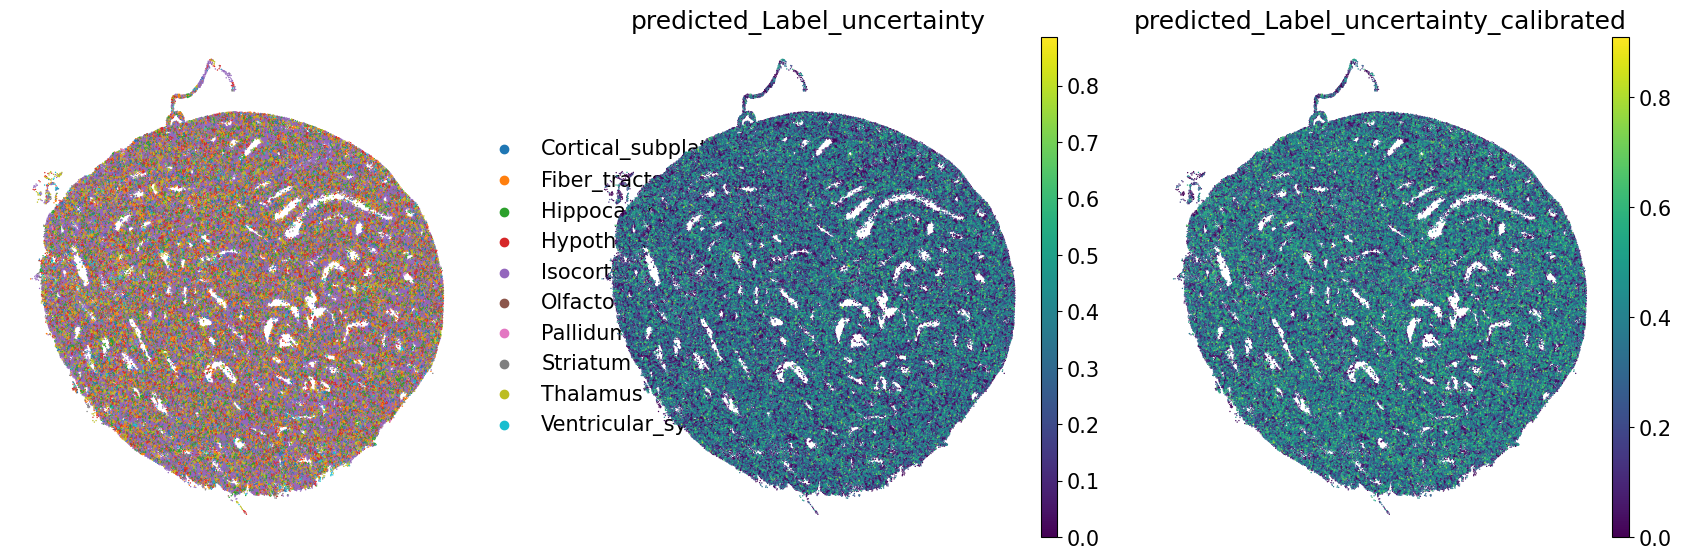

In [21]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,6.5)
plt.rcParams['font.size'] = 15
sc.pl.embedding(adata_batch2, basis="spatial",s=4,color=['predicted_Label','predicted_Label_uncertainty','predicted_Label_uncertainty_calibrated'],title='',frameon=False)

### Predictive labels and uncertainties of same tissues

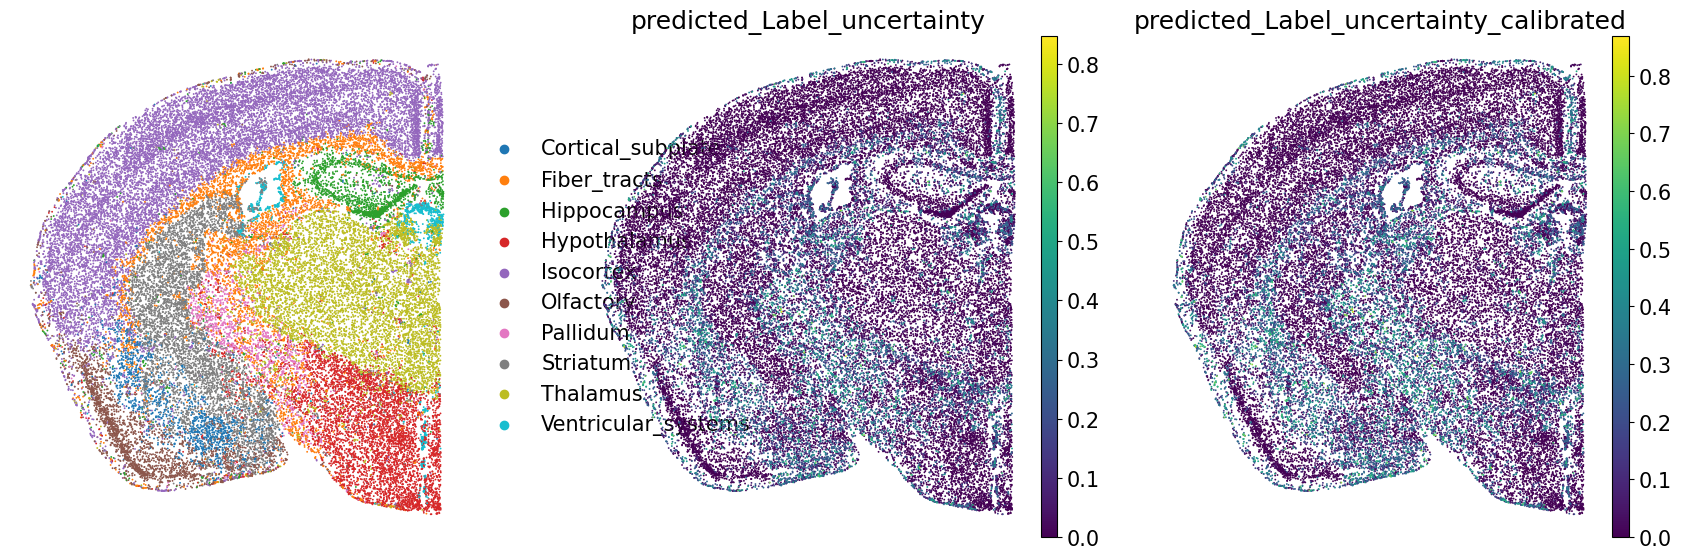

In [22]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,6.5)
plt.rcParams['font.size'] = 15
sc.pl.embedding(adata_batch3, basis="spatial",s=7,color=['predicted_Label','predicted_Label_uncertainty','predicted_Label_uncertainty_calibrated'],title='',frameon=False)

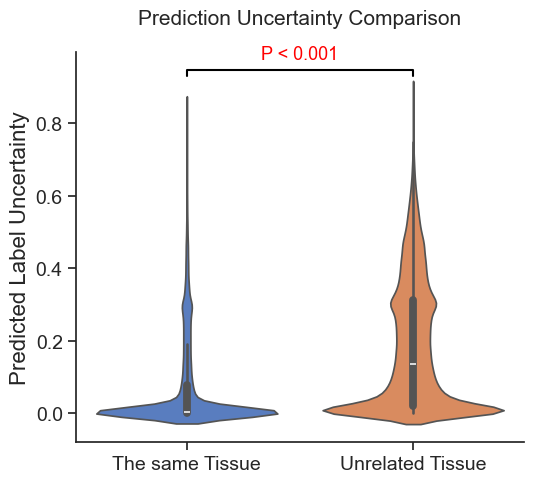

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

uncert_batch2 = adata_batch2.obs['predicted_Label_uncertainty'].values
uncert_batch3 = adata_batch3.obs['predicted_Label_uncertainty'].values

df3 = pd.DataFrame({'Uncertainty': uncert_batch2, 'Tissue': 'Unrelated Tissue'})
df2 = pd.DataFrame({'Uncertainty': uncert_batch3, 'Tissue': 'The same Tissue'})
df_plot = pd.concat([df2, df3], ignore_index=True)

stat, p_value = mannwhitneyu(uncert_batch2, uncert_batch3, alternative='two-sided')

plt.figure(figsize=(5.5, 5)) 
sns.set_theme(style="ticks")

ax = sns.violinplot(x='Tissue', y='Uncertainty', data=df_plot, palette="muted", inner="box")

plt.title('Prediction Uncertainty Comparison', fontsize=15, pad=20)
plt.ylabel('Predicted Label Uncertainty', fontsize=16)
plt.xlabel('', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

y_max = df_plot['Uncertainty'].max()
y_range = y_max - df_plot['Uncertainty'].min()

bar_y = y_max + (y_range * 0.05)
bar_height = y_range * 0.02
plt.plot([0, 0, 1, 1], [bar_y, bar_y + bar_height, bar_y + bar_height, bar_y], lw=1.5, c='black')

p_text = f'P < 0.001' if p_value < 0.001 else f'P = {p_value:.3f}'
plt.text(0.5, bar_y + bar_height + (y_range * 0.02), p_text, 
         ha='center', va='bottom', fontsize=13, color='red')

sns.despine()
plt.tight_layout()

plt.savefig('/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/unrelatedtissues/violin.png', dpi=500, bbox_inches='tight')

plt.show()